## Exploratory Data Analysis – CMAPSS Dataset

> **Note**  
> These notebooks is intended as a **high‑level demonstration** of a training workflow.
> The actual production‑ready pipeline (including hyperparameter tuning with Optuna, model registration in MLflow, thorough evaluation to fastAPI implementation) is implemented in the Python scripts

In [1]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load and Inspect Raw Data
Load the training data (FD001) and assign column names. Display basic info and summary statistics.

In [2]:

def load_raw_data():
    df = None
    filepath = "../data/raw/CMAPSSData/train_FD001.txt"
    df = pd.read_csv(filepath,sep=r"\s+", header=None)
    df.columns = ["engine_id","cycle","op_setting_1","op_setting_2","op_setting_3"] + [f"s{i+1}" for i in range(df.shape[1] -5)] 
    
    return df

df =load_raw_data()
df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   engine_id     20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   s1            20631 non-null  float64
 6   s2            20631 non-null  float64
 7   s3            20631 non-null  float64
 8   s4            20631 non-null  float64
 9   s5            20631 non-null  float64
 10  s6            20631 non-null  float64
 11  s7            20631 non-null  float64
 12  s8            20631 non-null  float64
 13  s9            20631 non-null  float64
 14  s10           20631 non-null  float64
 15  s11           20631 non-null  float64
 16  s12           20631 non-null  float64
 17  s13           20631 non-null  float64
 18  s14           20631 non-nu

In [4]:
print(df.describe())

          engine_id         cycle  op_setting_1  op_setting_2  op_setting_3  \
count  20631.000000  20631.000000  20631.000000  20631.000000       20631.0   
mean      51.506568    108.807862     -0.000009      0.000002         100.0   
std       29.227633     68.880990      0.002187      0.000293           0.0   
min        1.000000      1.000000     -0.008700     -0.000600         100.0   
25%       26.000000     52.000000     -0.001500     -0.000200         100.0   
50%       52.000000    104.000000      0.000000      0.000000         100.0   
75%       77.000000    156.000000      0.001500      0.000300         100.0   
max      100.000000    362.000000      0.008700      0.000600         100.0   

             s1            s2            s3            s4            s5  ...  \
count  20631.00  20631.000000  20631.000000  20631.000000  2.063100e+04  ...   
mean     518.67    642.680934   1590.523119   1408.933782  1.462000e+01  ...   
std        0.00      0.500053      6.131150     

### 2. Sensor Readings Over Cycle
Plot sensor values across cycles for three different engines to observe degradation patterns.

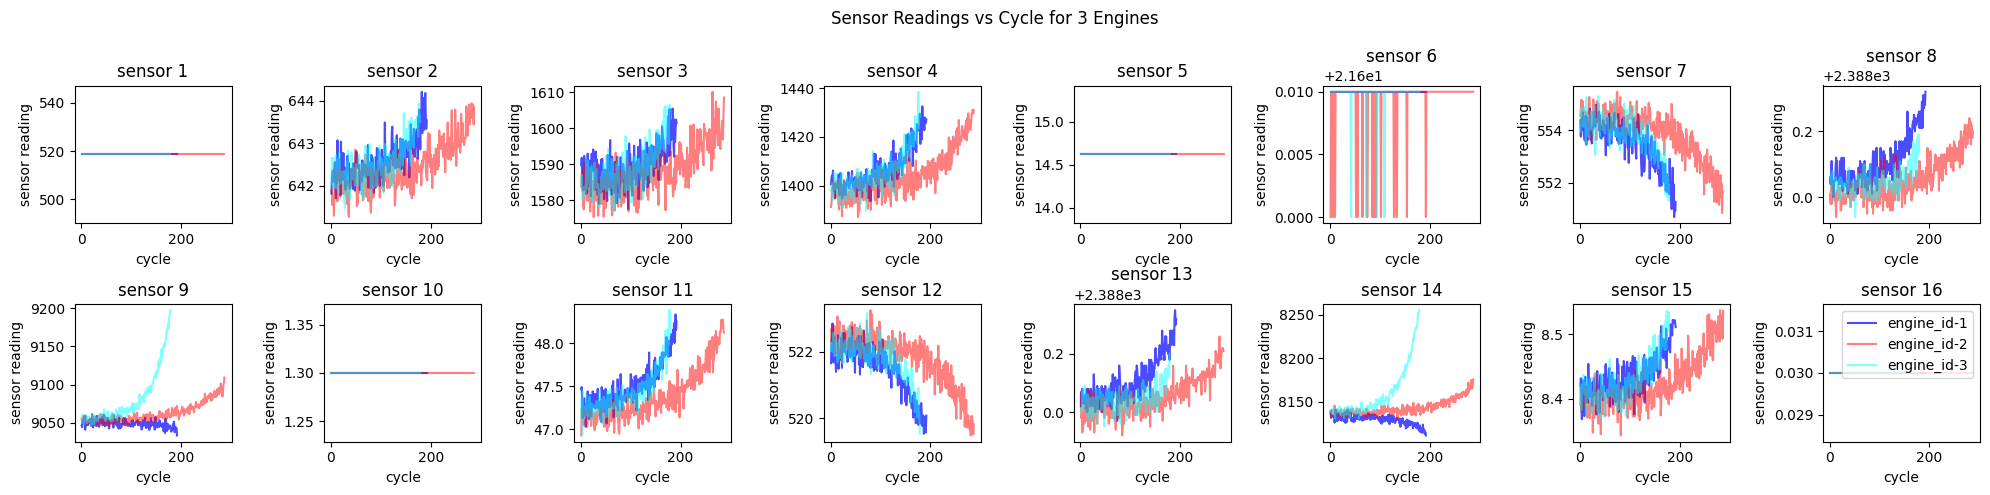

In [5]:

df_plot_1 = df[df["engine_id"]==1]
df_plot_2 = df[df["engine_id"]==2]
df_plot_3 = df[df["engine_id"]==3]

fig, axes = plt.subplots (nrows=2, ncols=8, figsize=(20, 5))
ax = axes.flatten()

colors = ["blue", 'red', 'cyan']

for s in range(1, df_plot_1.shape[1]-9):

    ax[s-1].plot(df_plot_1["cycle"], df_plot_1[f"s{s}"], color=colors[0], alpha=0.7, label='engine_id-1')
    ax[s-1].plot(df_plot_2["cycle"], df_plot_2[f"s{s}"], color=colors[1], alpha=0.5, label='engine_id-2')
    ax[s-1].plot(df_plot_3["cycle"], df_plot_3[f"s{s}"], color=colors[2], alpha=0.5, label='engine_id-3') 

    ax[s-1].set_title(f"sensor {s}")
    ax[s-1].set_xlabel('cycle')
    ax[s-1].set_ylabel('sensor reading')

plt.suptitle(f"Sensor Readings vs Cycle for 3 Engines")
plt.tight_layout()
plt.legend()
plt.show()


### 3. Compute RUL
RUL is defined as the number of cycles remaining until failure:  
`RUL = max(cycle) - cycle` for each engine.

In [6]:
def compute_rul(df):

    df['RUL'] = df.groupby('engine_id')['cycle'].transform('max') - df['cycle']  

    return df

df = compute_rul(df)
df.head() 


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


### 4. Distribution of Maximum RUL
Histogram showing the maximum RUL of all engines (i.e., engine_id:1 total lifespan).

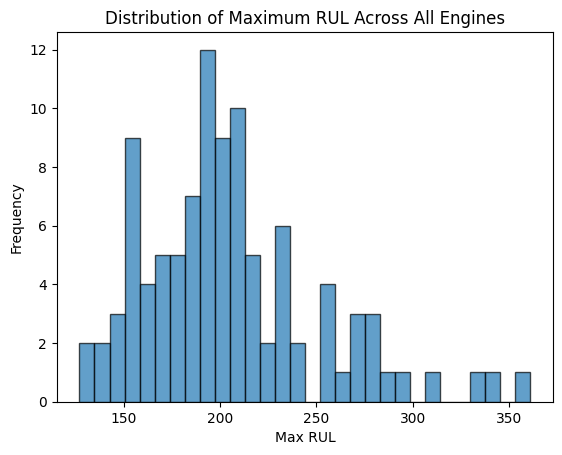

In [7]:

engines_max_rul = df.groupby('engine_id')['RUL'].max()


plt.hist(engines_max_rul, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Max RUL')
plt.ylabel('Frequency')
plt.title('Distribution of Maximum RUL Across All Engines')
plt.show()

### 5. Sensor Correlation Heatmap
Visualise correlations between sensors to identify highly correlated or redundant features (FD001).

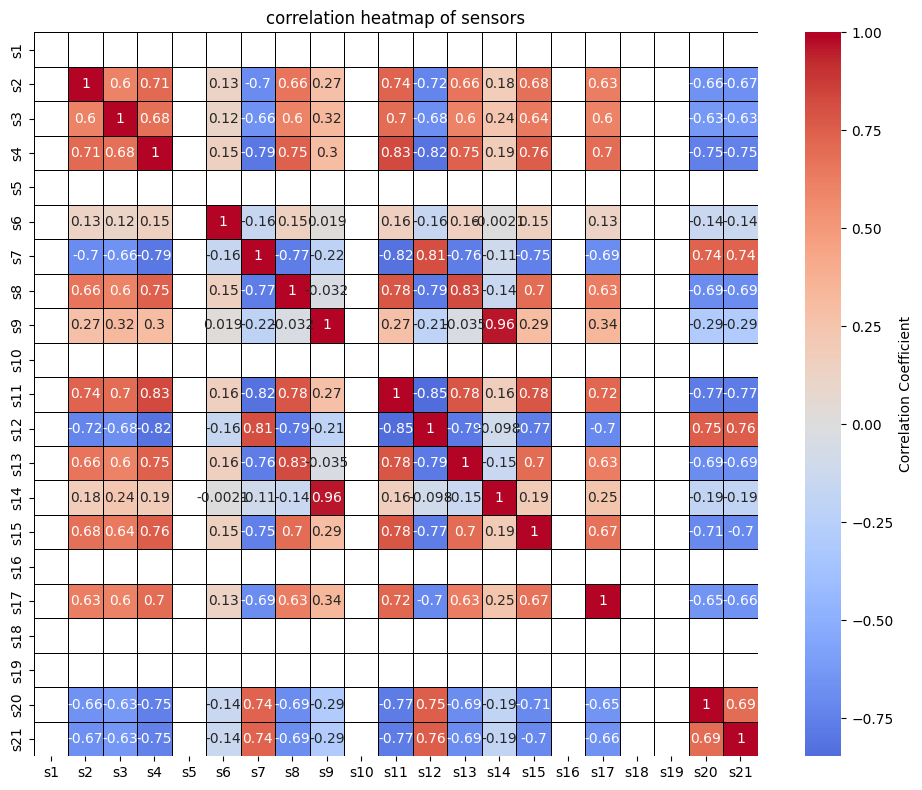

In [8]:

df_sensors = df.iloc[:, 5:-1]
df_sensors.columns

df_correlation = df_sensors.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(df_correlation, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5, linecolor='black', cbar_kws={"label": "Correlation Coefficient"})

plt.title('correlation heatmap of sensors')
plt.tight_layout()
plt.show()

### 6. Identify Low‑Variance Sensors
Sensors with near‑zero variance contribute little information and dropped later.
>These sensors likely measure constant operational settings rather than degrading components

In [9]:

df_sensors = df.iloc[:, 5:-1]
df_sens_var = df_sensors.var()
low_var_sensors = df_sens_var[df_sens_var<=1e-10].index.to_list()

low_var_sensors

['s1', 's5', 's10', 's16', 's18', 's19']

### 7. FD002 Dataset
Repeat some of the above steps for the second dataset to see differences.

In [10]:

def load_raw_data():
    df = None
    filepath = "../data/raw/CMAPSSData/train_FD002.txt"
    df = pd.read_csv(filepath,sep=r"\s+", header=None)
    df.columns = ["engine_id","cycle","op_setting_1","op_setting_2","op_setting_3"] + [f"s{i+1}" for i in range(df.shape[1] -5)] 
    
    return df

df =load_raw_data()
df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286


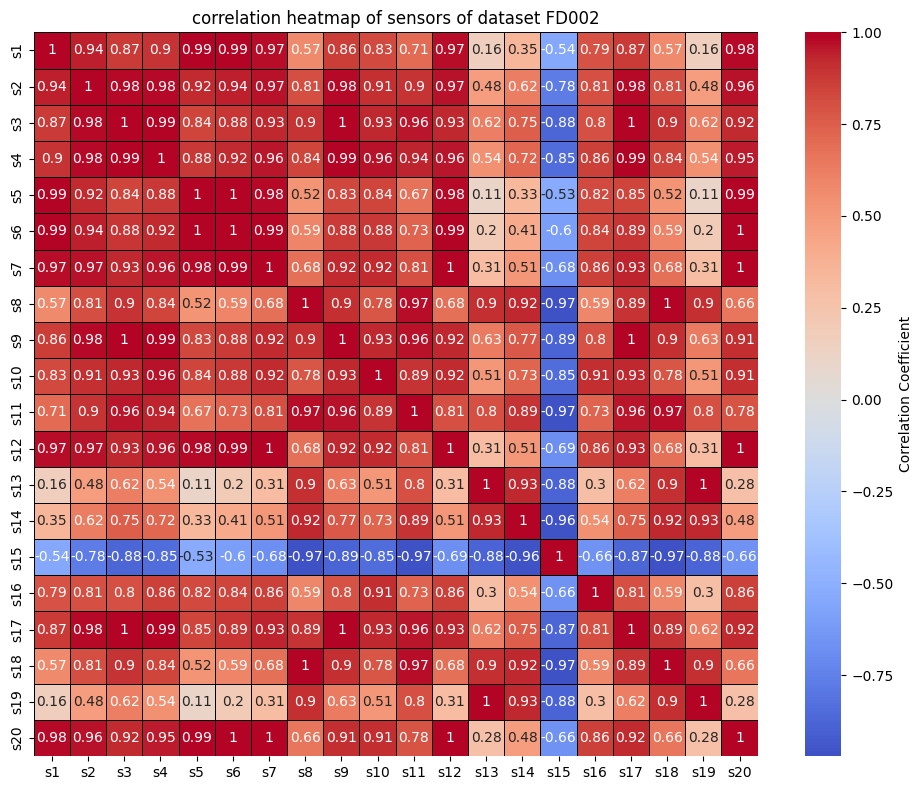

In [11]:
df_sensors = df.iloc[:, 5:-1]

df_correlation = df_sensors.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(df_correlation, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5, linecolor='black', cbar_kws={"label": "Correlation Coefficient"})

plt.title('correlation heatmap of sensors of dataset FD002')
plt.tight_layout()
plt.show()
